# 17.8 Variational Autoencoders

#### Data

2023-08-04 05:41:47.838741: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


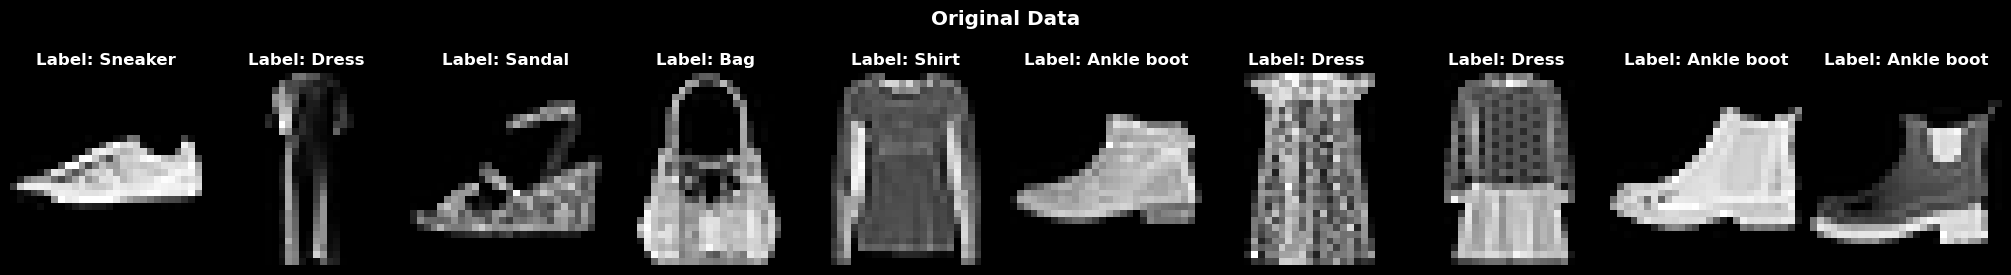

In [1]:
import load_fashion_mnist

(
    (x_train_norm, y_train),
    (x_valid_norm, y_valid),
    (x_test_norm, y_test),
) = load_fashion_mnist.load_data()

#### Model

In [2]:
import tensorflow as tf

class Sampling(tf.keras.layers.Layer):
    def call(self, inputs) -> tf.Tensor:
        means, log_var = inputs
        return tf.random.normal(shape=tf.shape(means), mean=means, stddev=tf.exp(log_var / 2))

In [3]:
coding_size = 10

input_encoder = tf.keras.layers.Input(shape=(28, 28))
flatten = tf.keras.layers.Flatten()(input_encoder)
hidden_1 = tf.keras.layers.Dense(200, activation="selu", kernel_initializer="lecun_normal")(flatten)
hidden_2 = tf.keras.layers.Dense(50, activation="selu", kernel_initializer="lecun_normal")(hidden_1)
codings_mu = tf.keras.layers.Dense(coding_size)(hidden_2)
codings_log_sigma2 = tf.keras.layers.Dense(coding_size)(hidden_2)
codings = Sampling()([codings_mu, codings_log_sigma2])
variational_encoder = tf.keras.Model(inputs=[input_encoder], outputs=[codings_mu, codings_log_sigma2, codings])

decoder_input = tf.keras.layers.Input(shape=(coding_size,))
hidden_4 = tf.keras.layers.Dense(50, activation="selu", kernel_initializer="lecun_normal")(decoder_input)
hidden_5 = tf.keras.layers.Dense(200, activation="selu", kernel_initializer="lecun_normal")(hidden_4)
hidden_6 = tf.keras.layers.Dense(28 * 28, activation="sigmoid")(hidden_5)
output = tf.keras.layers.Reshape(target_shape=(28, 28))(hidden_6)

variational_decoder = tf.keras.Model(inputs=[decoder_input], outputs=[output])

_, _, codings = variational_encoder(input_encoder)
reconstruction = variational_decoder(codings)
variational_ae = tf.keras.Model(inputs=[input_encoder], outputs=[reconstruction])

latent_loss = -0.5 * tf.reduce_sum(1 + codings_log_sigma2 - tf.math.exp(codings_log_sigma2) - tf.square(codings_mu), axis=-1)
variational_ae.add_loss(tf.reduce_mean(latent_loss) / 784.)

variational_ae.compile(optimizer="adam", loss="binary_crossentropy")
variational_ae.summary()

cb_early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)
history = variational_ae.fit(
    x_train_norm,
    x_train_norm,
    epochs=50,
    validation_data=[x_valid_norm, x_valid_norm],
    callbacks=[cb_early_stopping],
)

2023-08-04 05:41:50.608331: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-04 05:41:50.632249: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-04 05:41:50.632461: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-04 05:41:50.632900: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 28, 28)]     0           []                               
                                                                                                  
 model (Functional)             [(None, 10),         168070      ['input_1[0][0]']                
                                 (None, 10),                                                      
                                 (None, 10)]                                                      
                                                                                                  
 model_1 (Functional)           (None, 28, 28)       168334      ['model[0][2]']                  
                                                                                            

#### Evaluation

##### Reconstruction

313/313 [==============================] - 1s 1ms/step


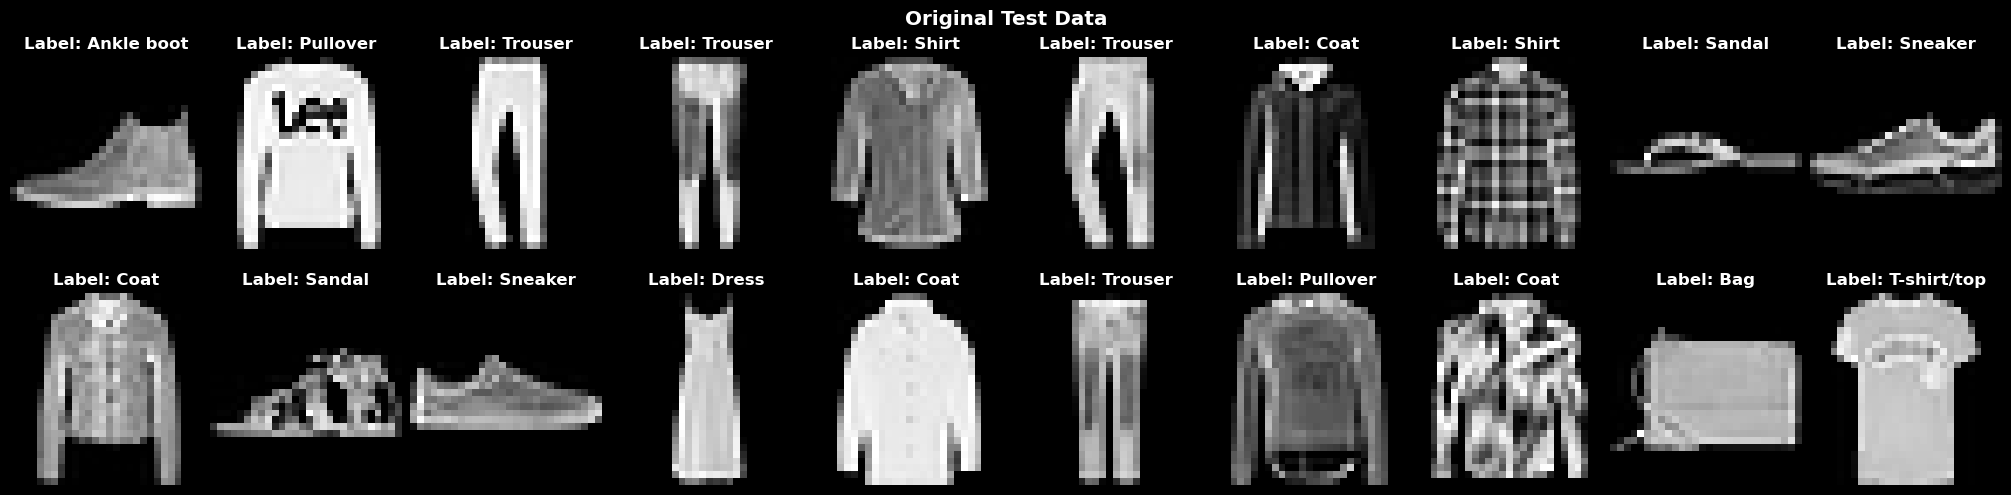

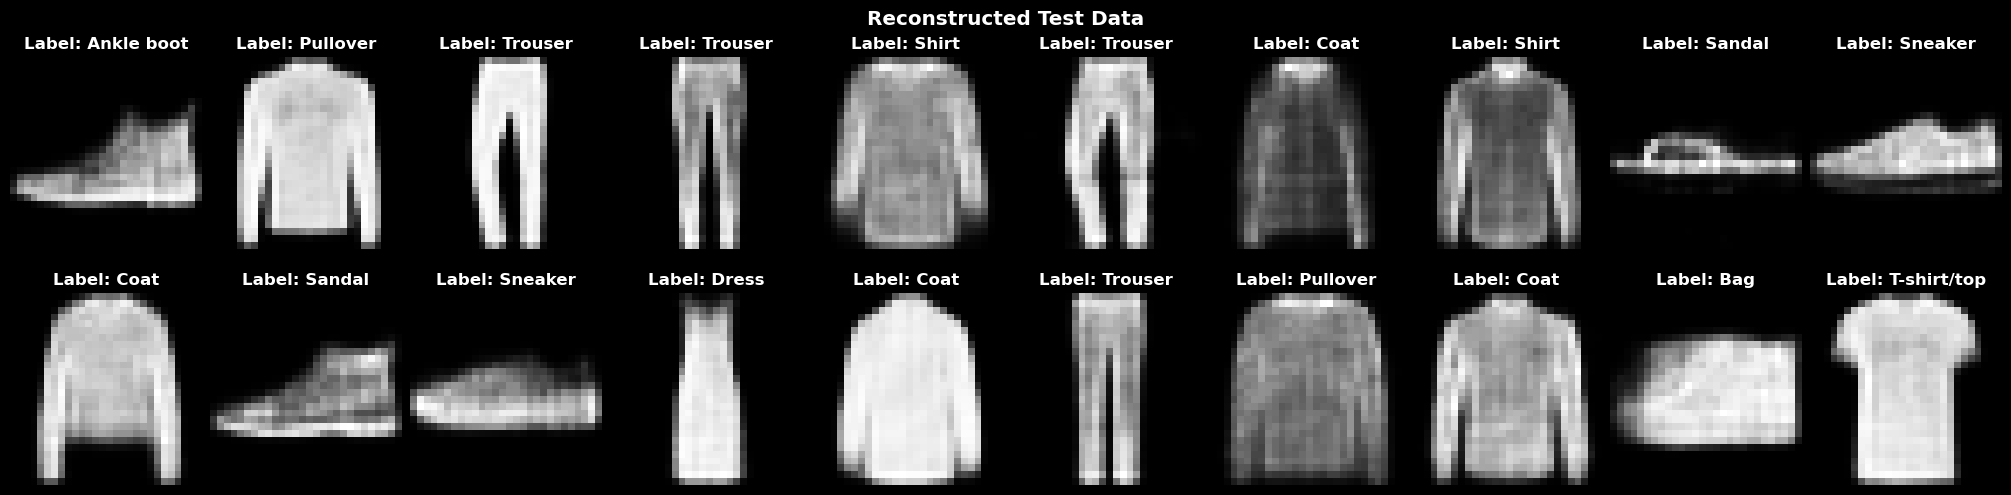

In [4]:
import evaluation

ev = evaluation.Evaluation(
    model=variational_ae,
    x_test=x_test_norm,
    y_test=y_test,
)
ev.reconstruction_test()

##### Generation

1/1 [==============================] - 0s 74ms/step


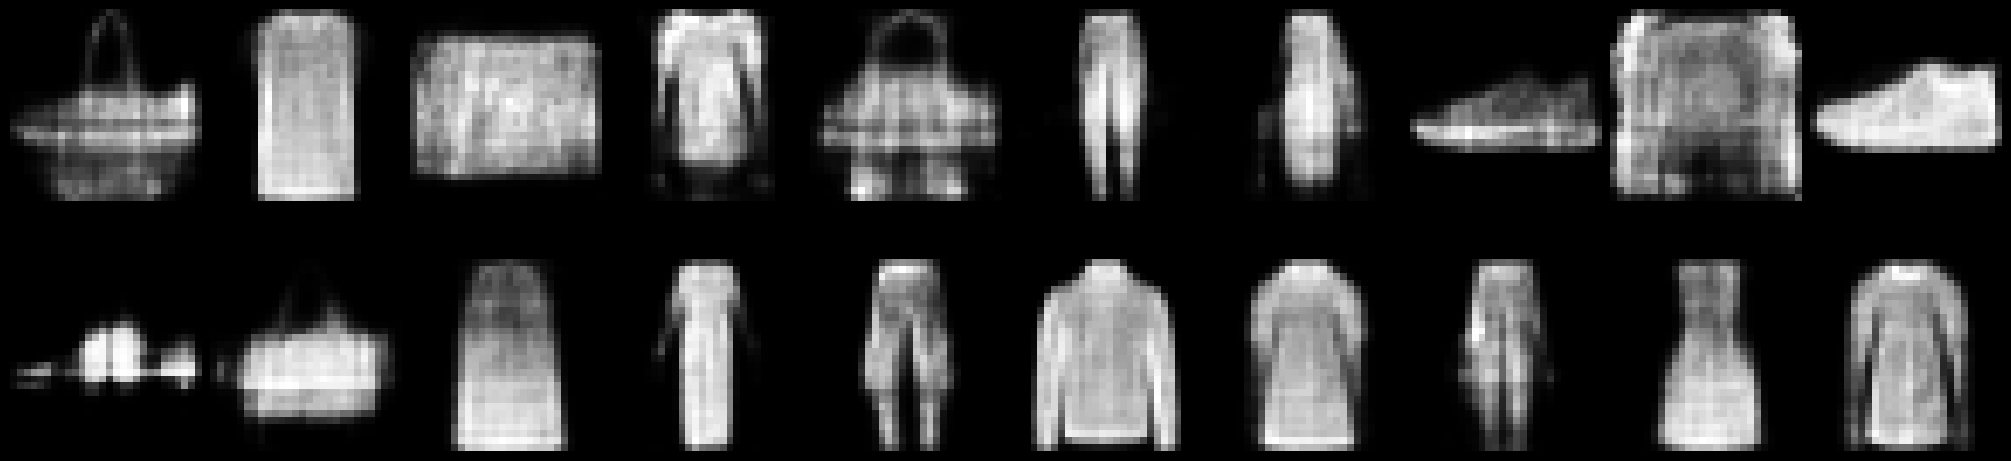

In [5]:
import importlib 

import plot_images

importlib.reload(plot_images)


n_samples = 20
codings_new = tf.random.normal((n_samples, coding_size))
samples_new = variational_decoder.predict(codings_new)

plot_images.plot_images(images_norm = samples_new)

##### Semantic Interpolation

2/2 [==============================] - 0s 2ms/step


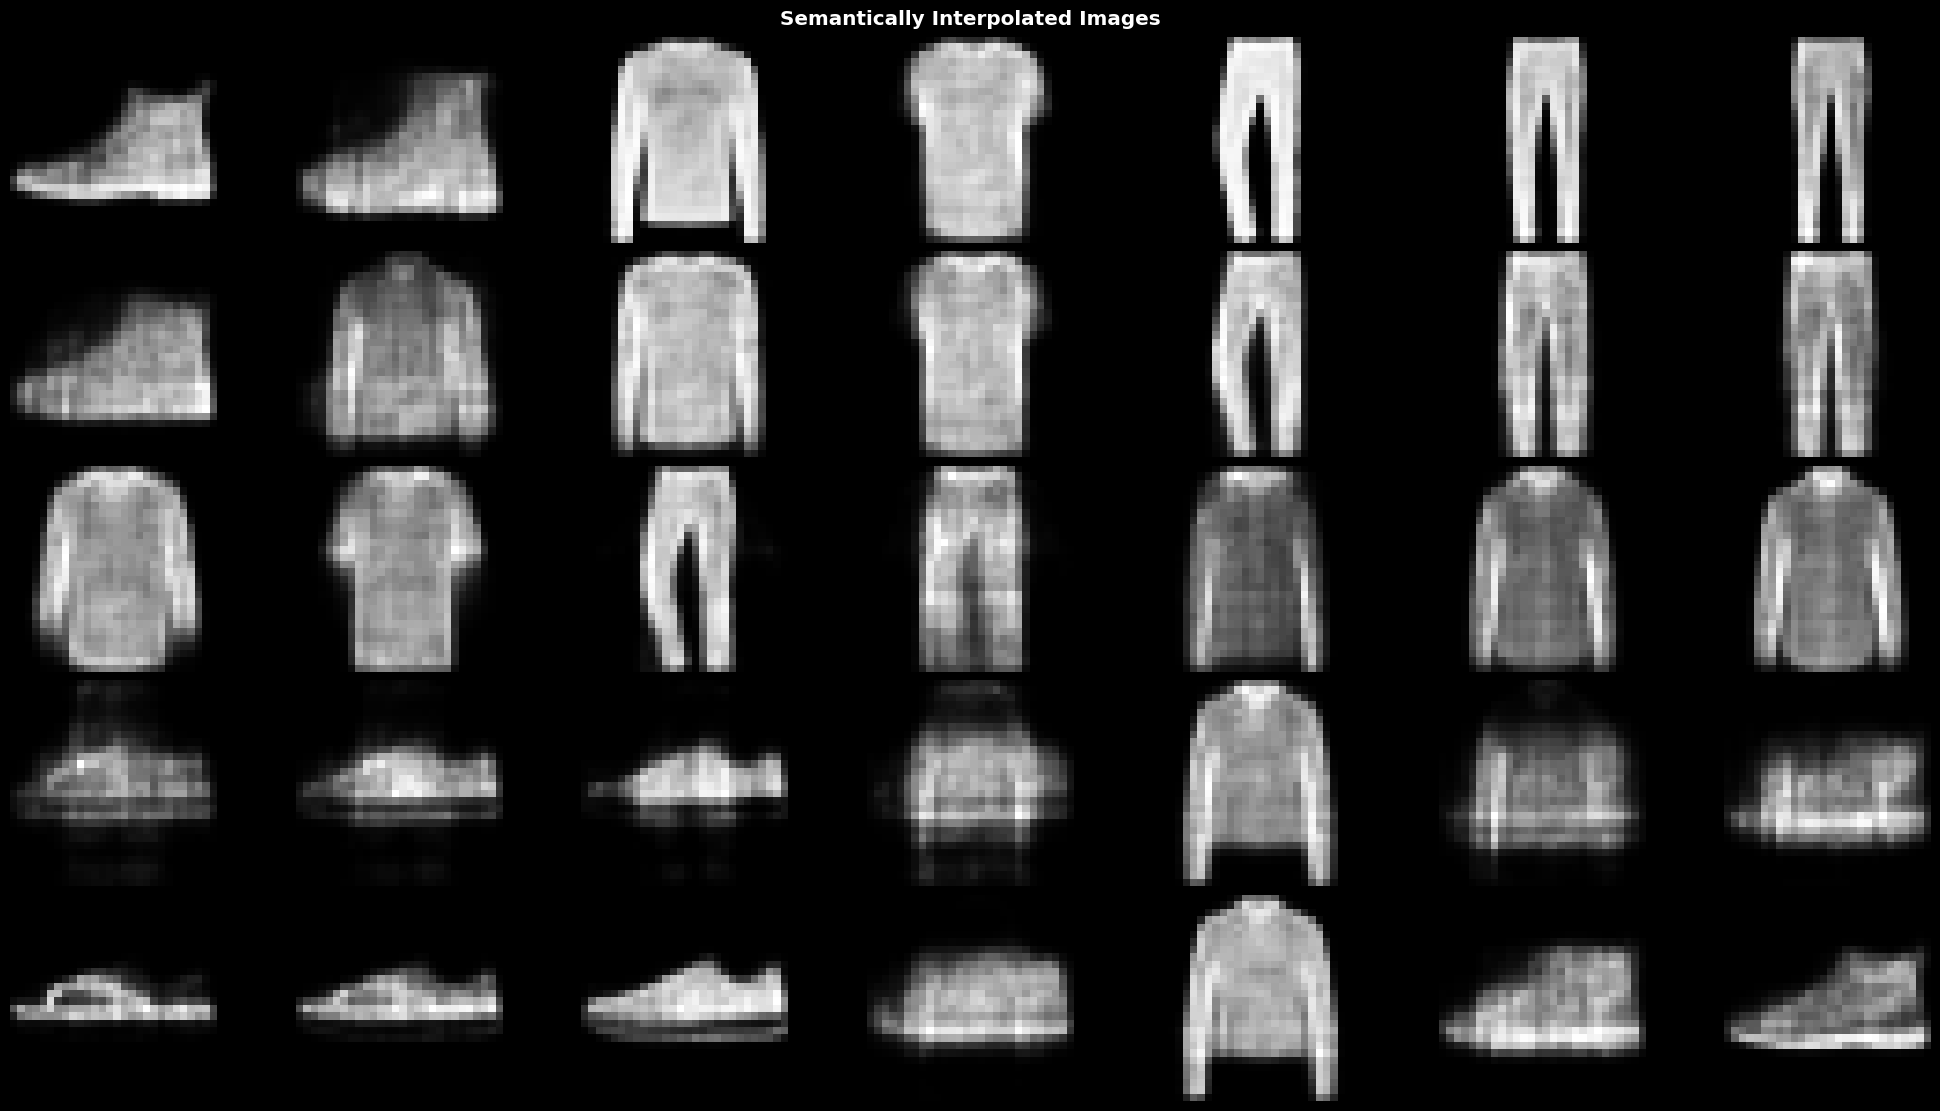

In [11]:
n_samples = 12
_, _, codings = variational_encoder.predict(x_test_norm[:n_samples])
codings_grid = tf.reshape(codings, (1, 3, 4, coding_size))
codings_interpolated = tf.image.resize(images=codings_grid, size=(5, 7))
codings_grid = tf.reshape(codings_interpolated, (-1, coding_size))
images_interpolated = variational_decoder.predict(codings_grid)
plot_images.plot_images(images_interpolated, n_cols = 7, sup_title="Semantically Interpolated Images")